In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import os

csv_filename = "/work/a3r/Documents/code/stac-scripts/catalog_thumbs/cmip_items/NOAA-GFDL/GFDL-SPEAR-MED/historical/day/psl/gr3/v20210201/psl_day_GFDL-SPEAR-MED_historical_gr3.csv"
df = pd.read_csv(csv_filename)

@np.vectorize
def _sfn(a):
    return int(a.split('i')[0][1:])

In [12]:
df.sort_values('member_id', key=_sfn, inplace=True)

In [16]:
mean_mean = df['mean'].mean()
std_means = df['mean'].std()

In [17]:
HEALTH_THRESHOLD_Z = 2.0 

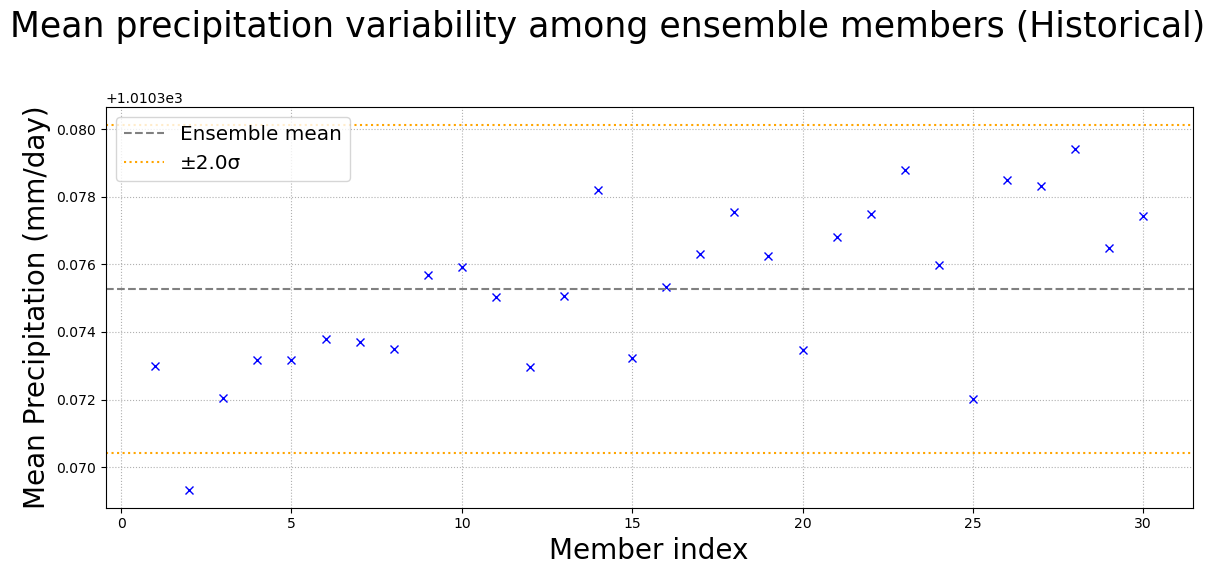

In [21]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Mean precipitation variability among ensemble members (Historical)', fontsize=25)

## --- Main Plot: Total per Member ---
ax1.set_xlabel('Member index', fontsize=20)
ax1.set_ylabel('Mean Precipitation (mm/day)', fontsize=20)

# Plot ALL members using the 'normal' style ('x-' in blue)
ax1.plot(_sfn(df['member_id']), df['mean'], 'x', color='blue', label='_nolegend_')


# Plot ensemble mean line (Mean of the totals)
ax1.axhline(mean_mean, color='grey', linestyle='--', label='Ensemble mean')

# Plot threshold lines based on the standard deviation of the totals
threshold_line_color = 'orange'
ax1.axhline(mean_mean + HEALTH_THRESHOLD_Z * std_means, 
            color=threshold_line_color, linestyle=':', 
            label=f'±{HEALTH_THRESHOLD_Z}σ')
ax1.axhline(mean_mean - HEALTH_THRESHOLD_Z * std_means, 
            color=threshold_line_color, linestyle=':',
            label='_nolegend_')

ax1.legend(fontsize='x-large')
ax1.grid(True, linestyle=':')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for main title